In [1]:
import numpy as np                  # Imported primarily for convenience, enable use of np.array
import matplotlib.pyplot as plt     # Used to generate the plots for Figures 1 and 2 in the paper
import subprocess                   # Used to run the binary created by mls.cpp

import sys                                 # Used to check if user is working on Windows or Linux
from IPython.display import HTML, display  # Used to crate an HTML table displaying all results

In [2]:
# This cell contains code to dislpay the convergence rates and absolte errors in HTML tables

def display_html_table_rates(data_dict, start_level=1):
    if not data_dict:
        return

    # Automatically infer column count from the length of the first numpy array
    first_r_sl = next(iter(data_dict.values()))[0]
    num_cols = len(first_r_sl)

    # Generate levels dynamically based on array length
    levels = range(start_level, start_level + num_cols)

    # Build header row
    headers = "".join(
        [f"<th style='padding:6px 12px;'>ℓ={l}</th>" for l in levels]
    )

    html = f"""
    <table style="border-collapse: collapse; font-family: sans-serif; text-align: center; margin: 10px 0;">
      <thead>
        <tr style="border-bottom: 2px solid black;">
          <th colspan="2" style="padding:6px 12px;"></th>
          {headers}
        </tr>
      </thead>
      <tbody>
    """

    for nu, (r_SL, r_ML) in data_dict.items():
        sl_cells = "".join(
            [f"<td style='padding:6px 12px;'>{val:.4f}</td>" for val in r_SL]
        )
        ml_cells = "".join(
            [f"<td style='padding:6px 12px;'>{val:.4f}</td>" for val in r_ML]
        )

        html += f"""
        <tr style="border-top: 1px solid #ccc;">
          <td rowspan="2" style="font-weight:bold; padding:6px 12px; vertical-align:middle;">ν = {nu}</td>
          <td style="padding:6px 12px;">𝔯<sub>SL</sub>(ℓ)</td>
          {sl_cells}
        </tr>
        <tr>
          <td style="padding:6px 12px;">𝔯<sub>ML</sub>(ℓ)</td>
          {ml_cells}
        </tr>
        """

    html += """
      </tbody>
    </table>
    """
    display(HTML(html))

def display_html_table_error(data_dict, start_level=1):
    if not data_dict:
        return

    # Automatically infer column count from the length of the first numpy array
    first_r_sl = next(iter(data_dict.values()))[0]
    num_cols = len(first_r_sl)

    # Generate levels dynamically based on array length
    levels = range(start_level, start_level + num_cols)

    # Build header row
    headers = "".join(
        [f"<th style='padding:6px 12px;'>ℓ={l}</th>" for l in levels]
    )

    html = f"""
    <table style="border-collapse: collapse; font-family: sans-serif; text-align: center; margin: 10px 0;">
      <thead>
        <tr style="border-bottom: 2px solid black;">
          <th colspan="2" style="padding:6px 12px;"></th>
          {headers}
        </tr>
      </thead>
      <tbody>
    """

    for nu, (e_SL, e_ML) in data_dict.items():
        sl_cells = "".join(
            [f"<td style='padding:6px 12px;'>{val:.4f}</td>" for val in e_SL]
        )
        ml_cells = "".join(
            [f"<td style='padding:6px 12px;'>{val:.4f}</td>" for val in e_ML]
        )

        html += f"""
        <tr style="border-top: 1px solid #ccc;">
          <td rowspan="2" style="font-weight:bold; padding:6px 12px; vertical-align:middle;">ν = {nu}</td>
          <td style="padding:6px 12px;">𝔈<sub>SL</sub>(ℓ)</td>
          {sl_cells}
        </tr>
        <tr>
          <td style="padding:6px 12px;">𝔈<sub>ML</sub>(ℓ)</td>
          {ml_cells}
        </tr>
        """

    html += """
      </tbody>
    </table>
    """
    display(HTML(html))

In [ ]:
# The funciton defined in this cell plots the figures and tables as seen in the paper

def err_plot(err_sl, err_ml, nu, filename=None):
    # Tell Matplotlib to use the STIX font set (includes Fraktur symbols)
    plt.rcParams['mathtext.fontset'] = 'stix'
    plt.rcParams['text.usetex'] = False
    
    iterations = np.arange(1, len(err_sl) + 1)  # 1, 2, ..., N

    frak_r_sl = np.log(err_sl[1:]/err_sl[:-1])/np.log(0.5)
    frak_r_ml = np.log(err_ml[1:]/err_ml[:-1])/np.log(0.5)

    plt.figure(figsize=(5,3))

    plt.plot(iterations, np.log10(err_sl), 'o--', markersize=4.5, label=r"$\mathfrak{E}_{SL}$")
    plt.plot(iterations, np.log10(err_ml), 'o--', markersize=4.5, label=r"$\mathfrak{E}_{ML}$")
    
    plt.xlabel('Level L')
    plt.ylabel('log(error)')

    plt.xticks(iterations)

    # Thinner bounding box (axes spines)
    for spine in plt.gca().spines.values():
        spine.set_linewidth(0.5)
    
    # Ensure last iteration number appears on the axis
    plt.xlim(1, len(iterations))
    
    plt.grid(True, linewidth=0.5)
    plt.legend()

    print("Table containing the logarithmic absolute errors (base 10):")
    display_html_table_error({nu: (np.log10(err_sl), np.log10(err_ml))})

    print("\n\nTable containing the level-wise convergence rates:")
    display_html_table_rates({nu: (frak_r_sl, frak_r_ml)})

    print("\n\nPlot showing the logarithmic absolute errors (base 10):")
    if filename is not None:
        plt.savefig(filename + ".pdf", bbox_inches="tight")
    else:
        plt.show()
    

In [26]:
# --- MLS Algorithm Parameters ---

# Initial mesh size parameter N: 
# The current implementation assumes an initial mesh size of the form h_0 = 1/N, 
# where N is an integer. To match the h_0 = 0.25 used in our examples, we set N = 4.
N = 4  

# Number of multilevel iterations L: 
# Note that the number of generated grid points grows exponentially with L. 
# Choosing an L that is too large will quickly exceed standard hardware memory limits.
L = 8

# Support-to-mesh-size ratio, denoted by \nu in the paper.
nu = 8.1

# Polynomial reproduction degree r: 
# The current code supports r = 0 and r = 1, which is sufficient to reproduce 
# the results in the paper. Higher degrees can be implemented analogously.
r = 0

# Note on the refinement rate \mu: 
# This is hardcoded to \mu = 0.5 in the current version. This ensures that grids 
# of subsequent levels are nested, which significantly improves execution time.

# Note on the kernel \Phi: 
# The Wendland function \Phi_{2,3} is used by default. To use a different kernel, 
# edit the function `inline double phi(double r)` in `mls.cpp`. The C++ code assumes 
# the kernel is radial (i.e., \Phi(x) = \phi(||x||)) and supported in the unit ball.

# Target function selection:
# Set example = 1 to approximate f(x) = ||x - (0.5, 0.5)^T||^{4+\epsilon} (Example 4.1).
# Set example = 2 to approximate f(x) = \sin(||x||^2)(1 + \cos(||x||^2)) (Example 4.2).
# Set example = 3 (or any integer other than 1 or 2) to use a custom function. 
# To define a custom function, edit `inline double custom_f(double x, double y)` in `mls.cpp`.
example = 2

Table containing the logarithmic absolute errors (base 10):




Table containing the level-wise convergence rates:




Plot showing the logarithmic absolute errors (base 10):


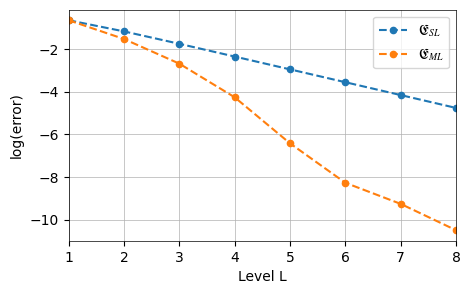

In [27]:
# Run the multilevel MLS algorithm by executing the binary mls.bin created by compiling mls.cpp, then plot the results.

bin_path = ["wsl", "./mls.bin"] if sys.platform == "win32" else ["./mls.bin"]
result   = subprocess.run(bin_path + [str(N), str(L), str(nu), str(r), str(example)], check=True)
data     = np.loadtxt("errors.csv", delimiter=",")

error_sl = data[0]
error_ml = data[1]

err_plot(error_sl, error_ml, nu)